h = 0.01
  y(15.000) ≈ 0.231440
  Exact ≈ 0.272375
  Local error ≈ 0.040935
  Avg error ≈ 0.368561

h = 0.05
  y(15.000) ≈ 0.119869
  Exact ≈ 0.272375
  Local error ≈ 0.152506
  Avg error ≈ 1.258792

h = 0.15
  y(15.000) ≈ 0.020921
  Exact ≈ 0.272375
  Local error ≈ 0.251454
  Avg error ≈ 1.950547

h = 0.2
  y(15.000) ≈ 0.007903
  Exact ≈ 0.272375
  Local error ≈ 0.264472
  Avg error ≈ 2.059003

h = 0.25
  y(15.000) ≈ 0.002662
  Exact ≈ 0.272375
  Local error ≈ 0.269713
  Avg error ≈ 2.130091

h = 0.5
  y(15.000) ≈ 0.000000
  Exact ≈ 0.272375
  Local error ≈ 0.272375
  Avg error ≈ 2.239393

h = 0.75
  y(15.000) ≈ 0.001574
  Exact ≈ 0.272375
  Local error ≈ 0.270801
  Avg error ≈ 2.186116

h = 1.0
  y(15.000) ≈ 0.808593
  Exact ≈ 0.272375
  Local error ≈ 0.536218
  Avg error ≈ 1.569795



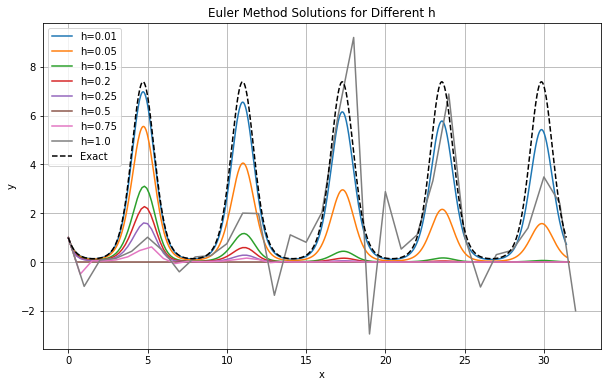

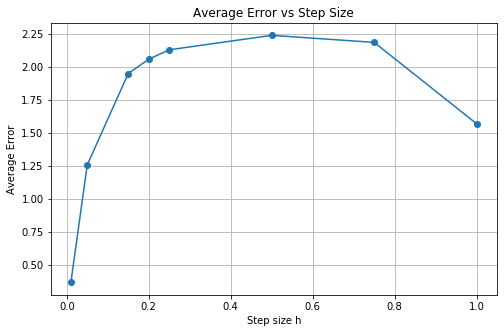

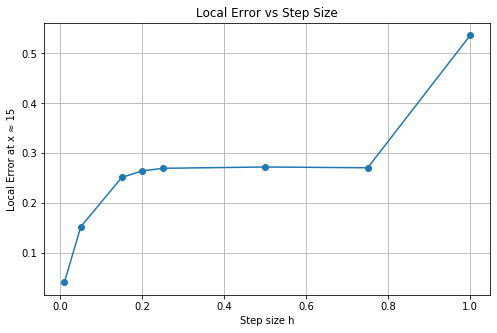

So generally speaking, the average error will increase as h increases. This is because euler only does well with small steps, the smaller, the better. 
However, The local error is not always the same because of the oscillations. At X=15, we can see that the error is pretty consistent until h=1, in which case it becomes significantly higher due to its instability. 
We can see that the average global error increases until h=1, at which point it stops following the trend of the previous h-values because it becomes very chaotic.


In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Exact solution
def y_exact(x):
    return np.exp(-2 * np.sin(x))

# Euler method
def euler(h, x_start, x_end):
    x_vals = np.arange(x_start, x_end + h, h)
    y_vals = np.zeros(len(x_vals))

    y_vals[0] = 1.0  # initial condition

    for i in range(1, len(x_vals)):
        y_vals[i] = y_vals[i-1] + h * (-2 * y_vals[i-1] * np.cos(x_vals[i-1]))

    return x_vals, y_vals

# Parameters
h_values = [0.01, 0.05, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]
x_start = 0
x_end = 10 * np.pi

avg_errors = []
local_errors = []
x_target = 15

plt.figure(figsize=(10, 6))

#Plot 1: Euler solutions
for h in h_values:
    x, y = euler(h, x_start, x_end)
    y_true = y_exact(x)

    # Plot Euler solution
    plt.plot(x, y, label=f"h={h}")

    # Compute average error
    error = np.abs(y - y_true)
    avg_errors.append(np.mean(error))

    # Find closest x to 15
    idx = np.argmin(np.abs(x - x_target))
    local_err = abs(y[idx] - y_exact(x[idx]))
    local_errors.append(local_err)

    print(f"h = {h}")
    print(f"  y({x[idx]:.3f}) ≈ {y[idx]:.6f}")
    print(f"  Exact ≈ {y_exact(x[idx]):.6f}")
    print(f"  Local error ≈ {local_err:.6f}")
    print(f"  Avg error ≈ {np.mean(error):.6f}\n")

x_fine = np.linspace(x_start, x_end, 2000)
plt.plot(x_fine, y_exact(x_fine), 'k--', label='Exact')

plt.title("Euler Method Solutions for Different h")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)
plt.show()

#Plot 2: Average error vs h
plt.figure(figsize=(8, 5))
plt.plot(h_values, avg_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Average Error")
plt.title("Average Error vs Step Size")
plt.grid(True)
plt.show()

#Plot 3: Local error near x = 15
plt.figure(figsize=(8, 5))
plt.plot(h_values, local_errors, marker='o')
plt.xlabel("Step size h")
plt.ylabel("Local Error at x ≈ 15")
plt.title("Local Error vs Step Size")
plt.grid(True)
plt.show()
print("So generally speaking, the average error will increase as h increases. This is because euler only does well with small steps, the smaller, the better. \nHowever, The local error is not always the same because of the oscillations. At X=15, we can see that the error is pretty consistent until h=1, in which case it becomes significantly higher due to its instability. \nWe can see that the average global error increases until h=1, at which point it stops following the trend of the previous h-values because it becomes very chaotic.")
